<a href="https://colab.research.google.com/github/M-USMAN-KHILJI/Real-Estate-Data-analyzation/blob/main/OPTIMUS_AUTOMATE_covid_19_Data_Analytics_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
upload  = files.upload()

Saving covid_19_clean_complete.csv to covid_19_clean_complete (3).csv


In [3]:
covid_19_df = pd.read_csv('covid_19_clean_complete.csv')
display(covid_19_df)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [4]:
covid_19_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [5]:
covid_19_df.describe()

,Lat,Long,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
std,24.950320,70.442740,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04
min,-51.796300,-135.000000,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


In [6]:
covid_19_df.isnull().sum()

,0
Province/State,34404
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [7]:
covid_19_df['Province/State'] = covid_19_df['Province/State'].fillna(covid_19_df['Province/State'].mode()[0])
covid_19_df.isnull().sum()

,0
Province/State,0
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


***looking for empty values and replacing them by using fillna and mode***

In [8]:
covid_19_df['month'] = pd.DatetimeIndex(covid_19_df['Date']).month
covid_19_df['year'] = pd.DatetimeIndex(covid_19_df['Date']).year

def load_covid_data(covid_19_df):
  covid_19_df['month'] = covid_19_df['month'].replace({
      1:'Jan',
      2:'Feb',
      3:'Mar',
      4:'Apr',
      5:'May',
      6:'Jun',
      7:'Jul',
      8:'Aug',
      9:'Sep',
      10:'Oct',
      11:'Nov',
      12:'Dec'
  })
  return covid_19_df
covid_19_df = load_covid_data(covid_19_df)
display(covid_19_df)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region,month,year
0,Alberta,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean,Jan,2020
1,Alberta,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe,Jan,2020
2,Alberta,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa,Jan,2020
3,Alberta,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe,Jan,2020
4,Alberta,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa,Jan,2020
...,...,...,...,...,...,...,...,...,...,...,...,...
49063,Alberta,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa,Jul,2020
49064,Alberta,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean,Jul,2020
49065,Alberta,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa,Jul,2020
49066,Alberta,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe,Jul,2020


***adding another column of munth and year to anaylze data more perfectly***

In [9]:
covid_19_df.duplicated().sum()

np.int64(0)

# ***which country are the most ?***

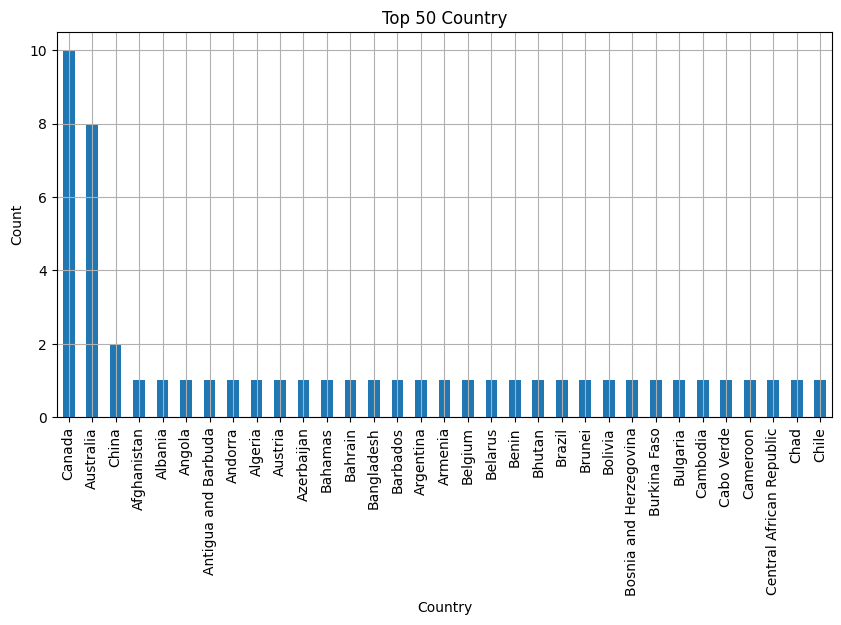

In [10]:
country = covid_19_df['Country/Region'].head(50).value_counts()
country.plot(kind='bar' , figsize=(10,5) , grid= 'Ture')
plt.title('Top 50 Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

***Canada is the most repeated country in the dataset***

# ***WHO REGION countries ?***

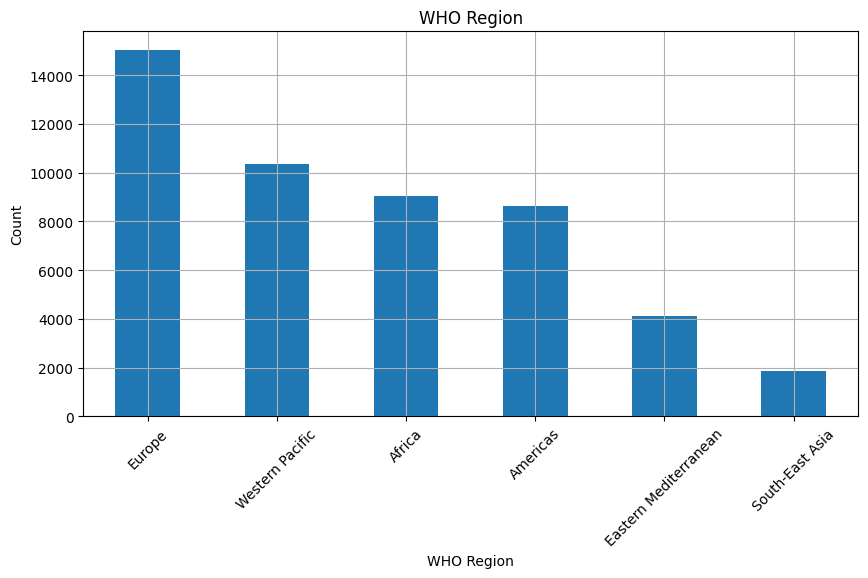

In [11]:
WHO_Region = covid_19_df['WHO Region'].value_counts()
WHO_Region.plot(kind='bar' , figsize=(10,5) , grid= 'Ture')
plt.title('WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## ***Europe is the top WHO Region***

## ***In which month most of the causes of covid 19 was comfirmed***

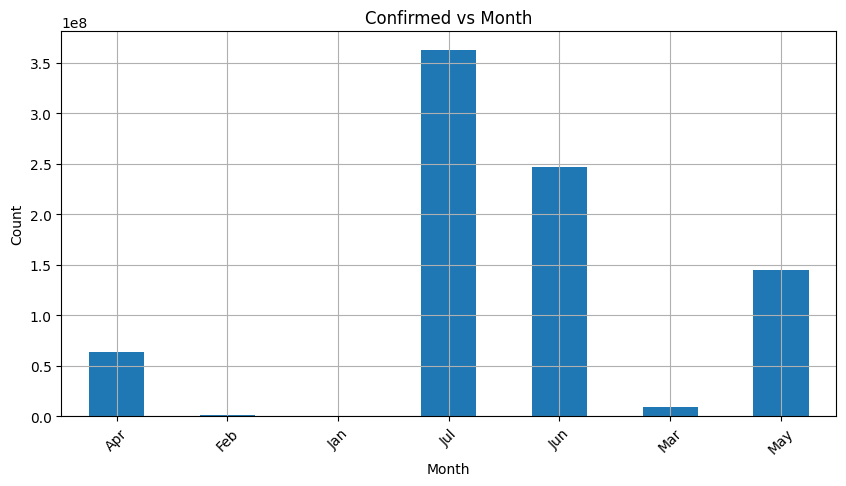

In [12]:
Confirmed_vs_month = covid_19_df.groupby('month')['Confirmed'].sum()
Confirmed_vs_month.plot(kind='bar' , figsize=(10,5) , grid= 'Ture' )
plt.title('Confirmed vs Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

***MOst of the cases of people having covid was comfirmed in july***

## ***In which month most people died ?***

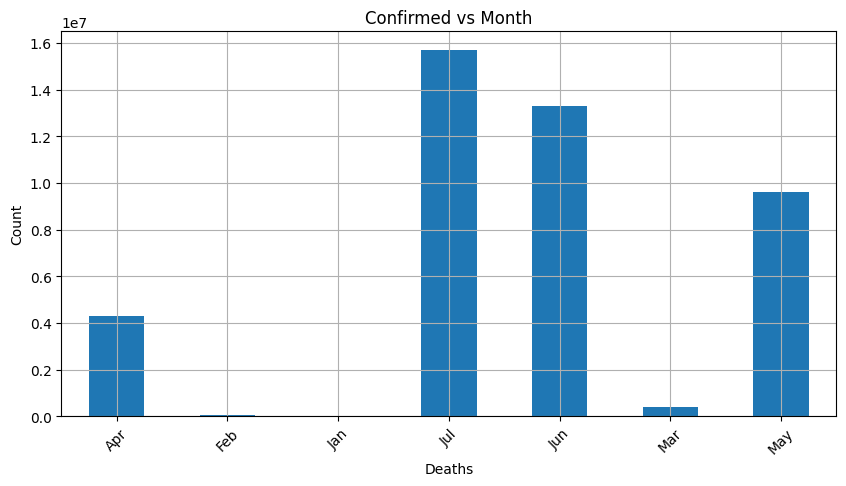

In [13]:
Deaths_vs_month = covid_19_df.groupby('month')['Deaths'].sum()
Deaths_vs_month.plot(kind='bar' , figsize=(10,5) , grid= 'Ture')
plt.title('Confirmed vs Month')
plt.xlabel('Deaths')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

***Many people dead because of covid in july***

## ***In which month most of the people recovered from covid 19 ?***

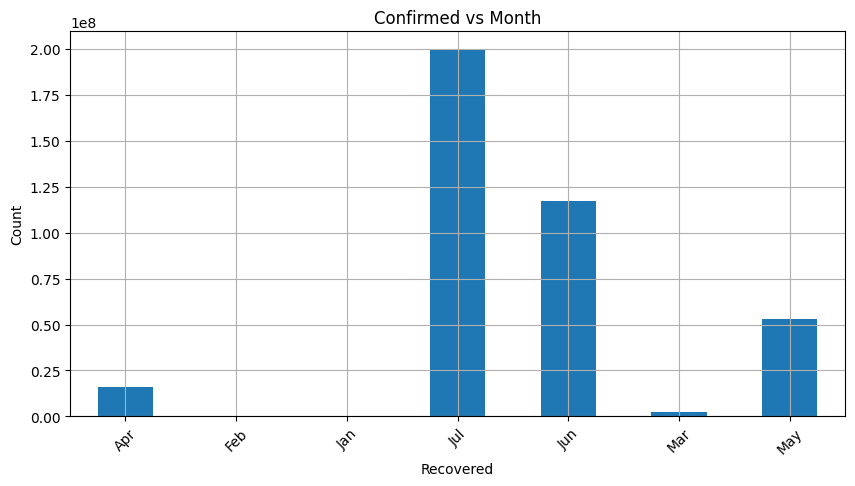

In [14]:
Recovered_vs_month = covid_19_df.groupby('month')['Recovered'].sum()
Recovered_vs_month.plot(kind='bar' , figsize=(10,5) , grid= 'Ture')
plt.title('Confirmed vs Month')
plt.xlabel('Recovered')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

***Many people recovered from covid in july***

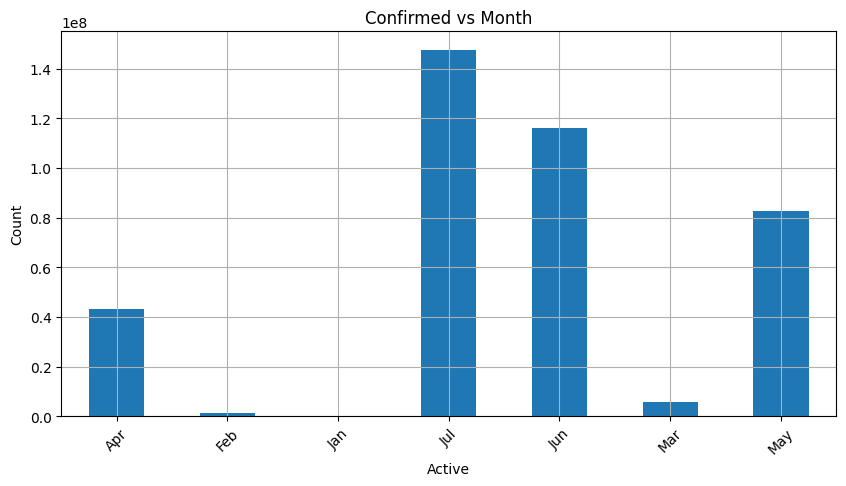

In [15]:
Active_VS_month = covid_19_df.groupby('month')['Active'].sum()
Active_VS_month.plot(kind='bar' , figsize=(10,5) , grid= 'Ture')
plt.title('Confirmed vs Month')
plt.xlabel('Active')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## ***Which country has the most causes of covid 19 ?***

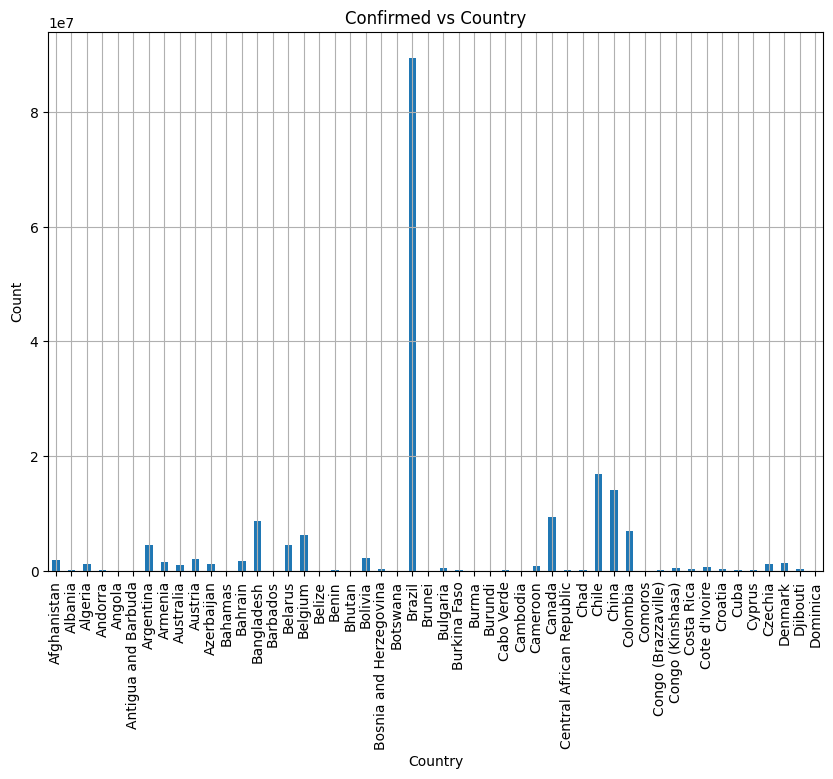

In [16]:
Country_VS_Confirmed = covid_19_df.groupby('Country/Region')['Confirmed'].sum().head(50)
Country_VS_Confirmed.plot(kind='bar' , figsize=(10,7) , grid= 'Ture' )
plt.title('Confirmed vs Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

***Brazil has the most causes of covid***

# ***Which country has the most rate of deaths because of covid ?***

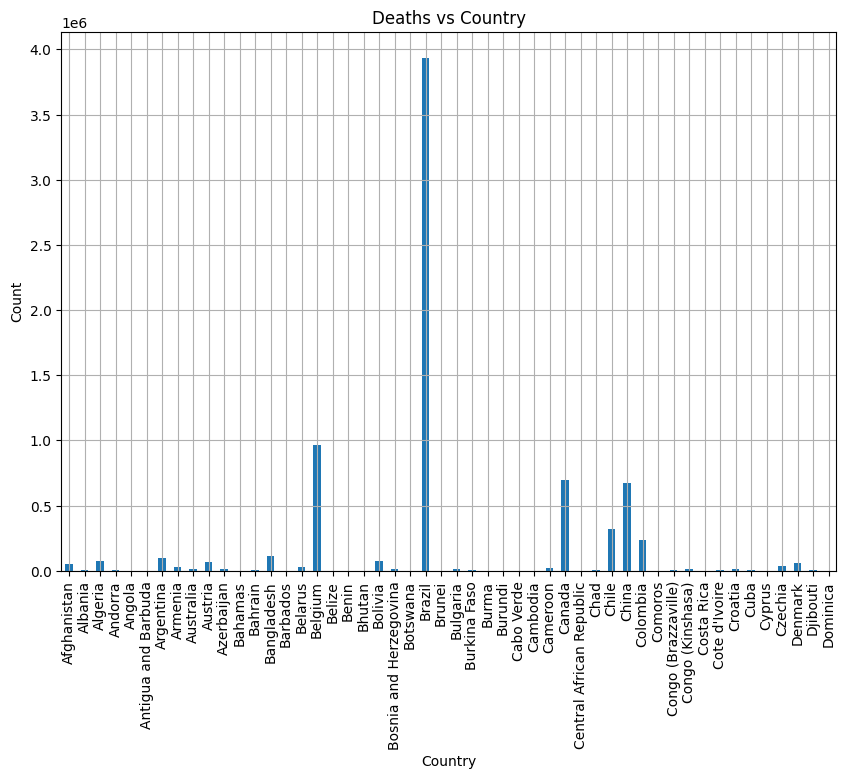

In [17]:
Country_VS_Deaths = covid_19_df.groupby('Country/Region')['Deaths'].sum().head(50)
Country_VS_Deaths.plot(kind='bar' , figsize=(10,7) , grid= 'Ture' )
plt.title('Deaths vs Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

***Brazil has the most rate of dead***

# ***In which country most people recovered ?***

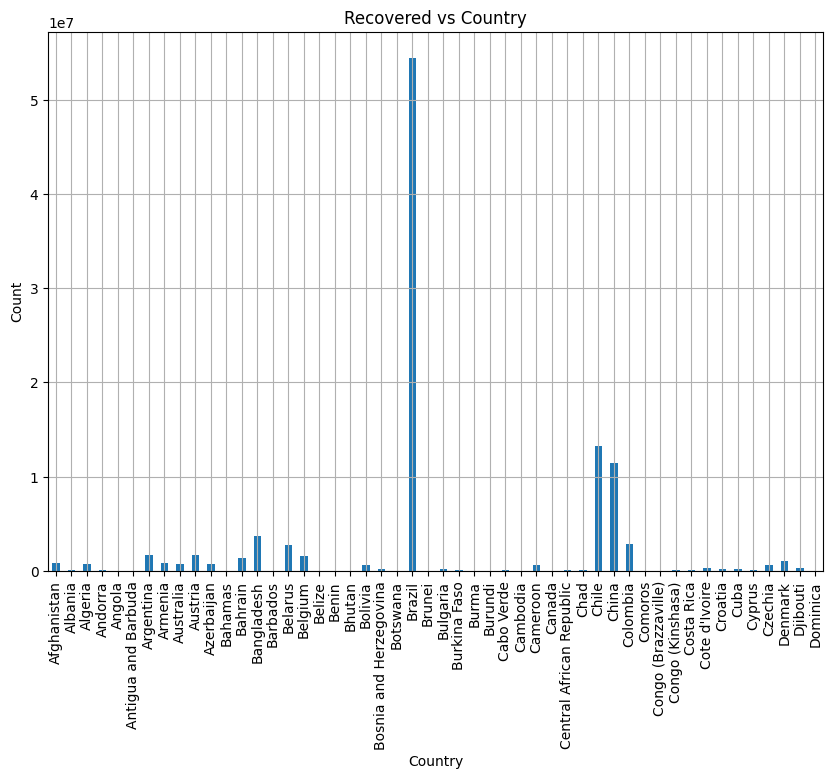

In [18]:
Country_VS_Recovered = covid_19_df.groupby('Country/Region')['Recovered'].sum().head(50)
Country_VS_Recovered.plot(kind='bar' , figsize=(10,7) , grid= 'Ture' )
plt.title('Recovered vs Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

***People recovered from covid in Brazil***

# ***whcih country was active ?***

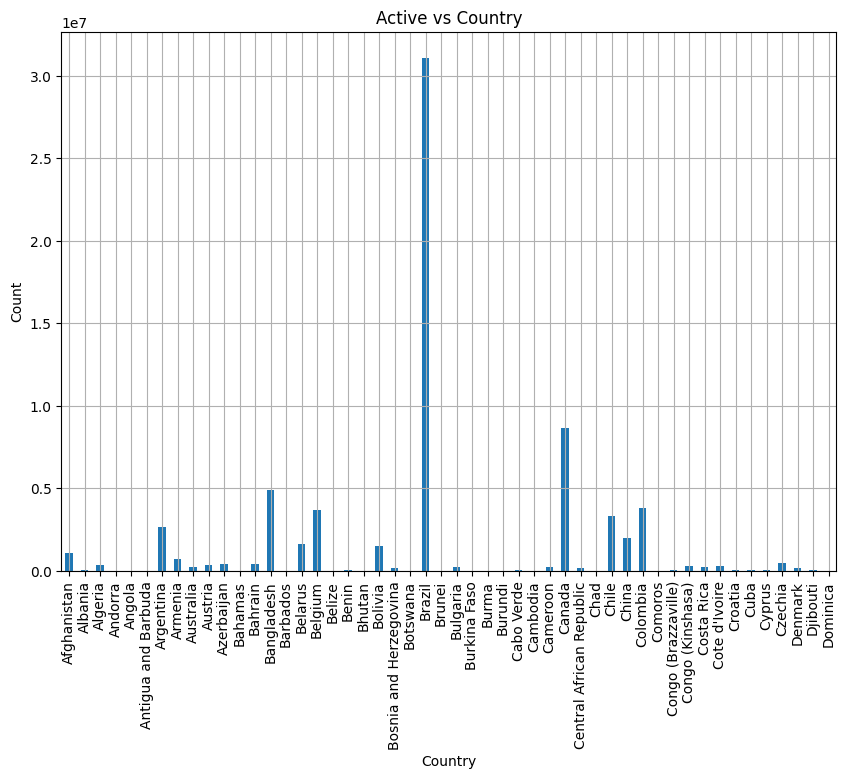

In [19]:
Country_VS_Active = covid_19_df.groupby('Country/Region')['Active'].sum().head(50)
Country_VS_Active.plot(kind='bar' , figsize=(10,7) , grid= 'Ture' )
plt.title('Active vs Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

***Brazil was the most avtive country***

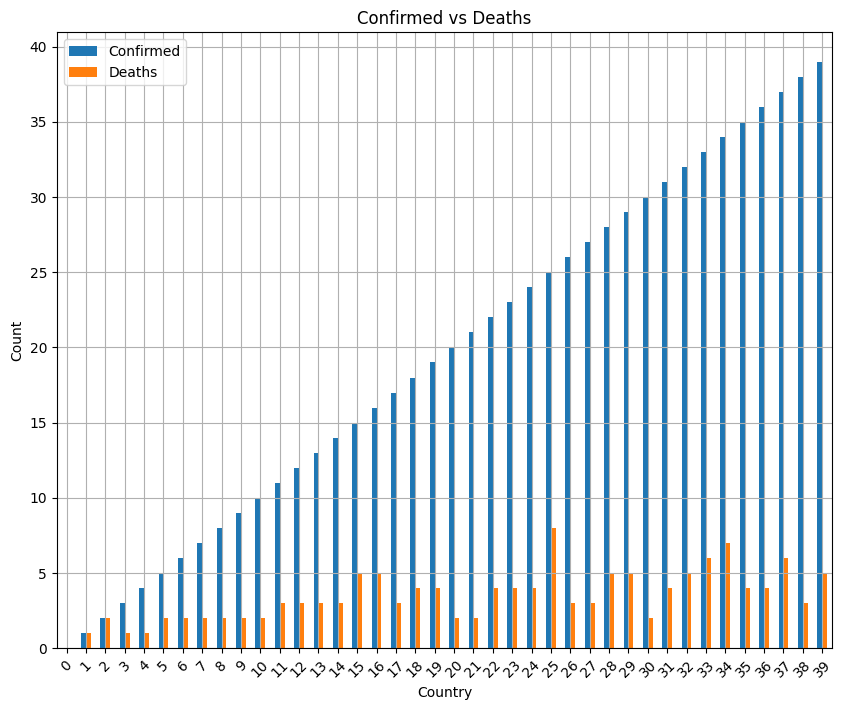

In [20]:
comfirmed_VS_deaths = covid_19_df.groupby('Confirmed')[['Deaths']].max().head(40).reset_index()
comfirmed_VS_deaths.plot(kind='bar' , figsize=(10,8) , grid= 'Ture' )
plt.title('Confirmed vs Deaths')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.show()